In [1]:
#Imports

import numpy as np
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
import matplotlib.pyplot as plt
import matplotlib
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
import warnings
warnings.filterwarnings("ignore")
from simpeg import (
    maps, data, data_misfit, regularization,
    optimization, inverse_problem, inversion, directives,utils,
)
from ipywidgets import widgets, interact
from pathlib import Path
from mtpy.core.mt_collection import MTCollection
mtc = MTCollection()
import mtpy as mt
import utm
import matplotlib.gridspec as gridspec
import scipy


#Solver for Mac
from pymatsolver import Mumps

matplotlib.rcParams['font.size'] = 14

### Geological Figure of Uranium Ore Body (Tuncer, 2017)

![My Image](Geological_Figures.png)

### Defining Properties and Plotting Layer Model

Text(0.5, 1.0, 'Depth vs. Sigma')

<Figure size 1000x500 with 0 Axes>

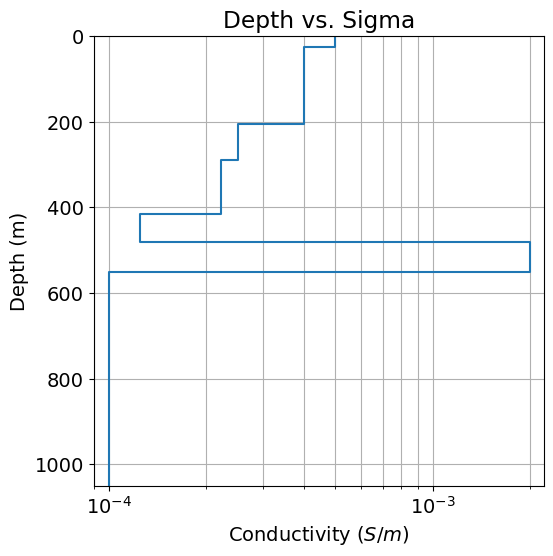

In [2]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 65,70,500]) #Thicknesses were obtained from Tuncer, pg. 16
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,500,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data

#Survey Properties
frequencies = np.r_[7.68*10**3, 5.12*10**3, 3.84*10**3, 1.28*10**3,
    9.59*10**2, 6.4*10**2, 4.64*10**2, 3.36*10**2, 2.4*10**2, 1.77*10**2, 1.28*10**2,
    9.699*10**1,8.1*10**1,7.1*10**1,6.1*10**1,5.1*10**1,4.1*10**1,3.275*10**1,2.225*10**1,1.512*10**1,1.025*10**1,
    6.937,4.875]  # frequencies in Hz # Obtained from Cameco Data, Line 304

#Obtaining max and min skin depths given frequencies and expected resisitivies
min_skin_depth = 503*np.sqrt(np.min(1/sigma)/frequencies.max())
max_skin_depth = 503*np.sqrt(np.max(1/sigma)/frequencies.min())



#Plotting 1D Layer Model for visualization
fig = plt.figure(figsize=(10, 5))
ax1 = plot_1d_layer_model(layer_thicknesses, sigma) # figure has base value at log plot
ax1.grid(which="both")
ax1.set_xlabel(r"Conductivity ($S/m$)")
ax1.set_title('Depth vs. Sigma')


In [3]:
#Plotting Skin Depths
print(f'Max Skin Depth: {max_skin_depth}')
print(f'Min Skin Depth: {min_skin_depth}')

Max Skin Depth: 22781.413926989266
Min Skin Depth: 128.34305631457696


### Defining Mesh

Text(0.5, 1.0, 'Tensor Mesh')

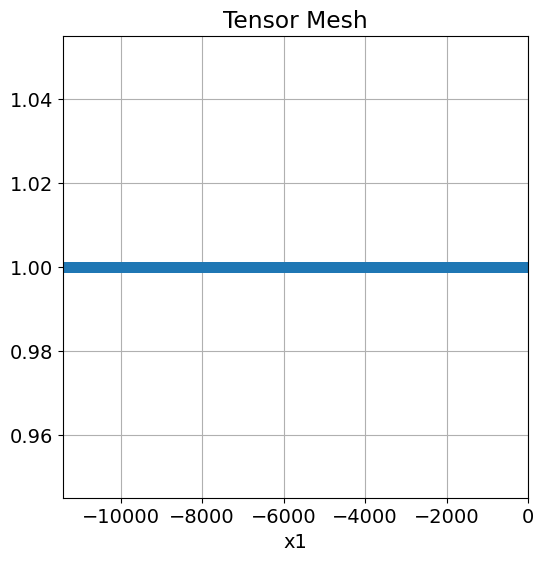

In [4]:
dx = 5  # base cell width x
ncx = max_skin_depth/2 * 1/dx  # number of core mesh cells in x
npad_x = 4  # number of padding cells in x
exp_x = 1  # expansion rate of padding cells in x

# Use a list of tuples to define cell widths in each direction. Each tuple
# contains the cell width, number of cells and the expansion factor. A
# negative sign is used to indicate an interval where cells widths go
# from largest to smallest.
hx = [(dx, npad_x, -exp_x), (dx, ncx)] #, (dx, npad_x, exp_x)]

# We can use flags 'C', '0' and 'N' to shift the xyz position of the mesh
# relative to the origin
mesh = TensorMesh([hx], x0 = "N")

# We can apply the plot_grid method and output to a specified axes object
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
mesh.plot_grid(ax=ax, nodes="True")
ax.set_xbound(mesh.x0[0], mesh.x0[0] + np.sum(mesh.h[0]))
ax.set_title("Tensor Mesh")

In [5]:
#Printing Mesh Values
mesh

TensorMesh: 2,282 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x   2282    -11,410.00          0.00      5.00      5.00    1.00

In [6]:
mesh.nodes

array([-1.1410e+04, -1.1405e+04, -1.1400e+04, ..., -1.0000e+01,
       -5.0000e+00,  0.0000e+00], shape=(2283,))

In [7]:
#Defining the sigma backround as the highest conducivity layer (overburden)
sigma_background = 1/2000

#Creating a model (ie. creating an array the same size as the mesh to represent each of the mesh's cells conductivity)
model = np.ones(mesh.n_cells) * sigma_background  # np.zeros(len(x_cells)) 


#Defining Layer Depths
layer_depths = np.array([layer_thicknesses[0],
                         layer_thicknesses[0] + layer_thicknesses[1],
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2],
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2] + layer_thicknesses[3],
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2] + layer_thicknesses[3] + layer_thicknesses[4], 
                         layer_thicknesses[0] + layer_thicknesses[1] + layer_thicknesses[2] + layer_thicknesses[3] + layer_thicknesses[4] + layer_thicknesses[5]])

    
# Defining indexes for layer depths/ depths of separations between layers
layer_1_model = (mesh.cell_centers >= -layer_depths[0])
layer_2_model = (mesh.cell_centers < -layer_depths[0]) & (mesh.cell_centers >= -layer_depths[1])
layer_3_model = (mesh.cell_centers < -layer_depths[1]) & (mesh.cell_centers >= -layer_depths[2])
layer_4_model = (mesh.cell_centers < -layer_depths[2]) & (mesh.cell_centers >= -layer_depths[3])
layer_5_model = (mesh.cell_centers < -layer_depths[3]) & (mesh.cell_centers >= -layer_depths[4])
layer_6_model_ore_body = (mesh.cell_centers < -layer_depths[4]) & (mesh.cell_centers >= -layer_depths[5])
layer_7_model = (mesh.cell_centers < -layer_depths[5])



#Assigning conductivities to each layer per indexes
model[layer_1_model] = sigma[0]
model[layer_2_model] = sigma[1]
model[layer_3_model] = sigma[2]
model[layer_4_model] = sigma[3]
model[layer_5_model] = sigma[4]
model[layer_6_model_ore_body] = sigma[5]
model[layer_7_model] = sigma[6]

print(model)


[0.0001 0.0001 0.0001 ... 0.0005 0.0005 0.0005]


Text(0, 0.5, 'Log_10(sigma)')

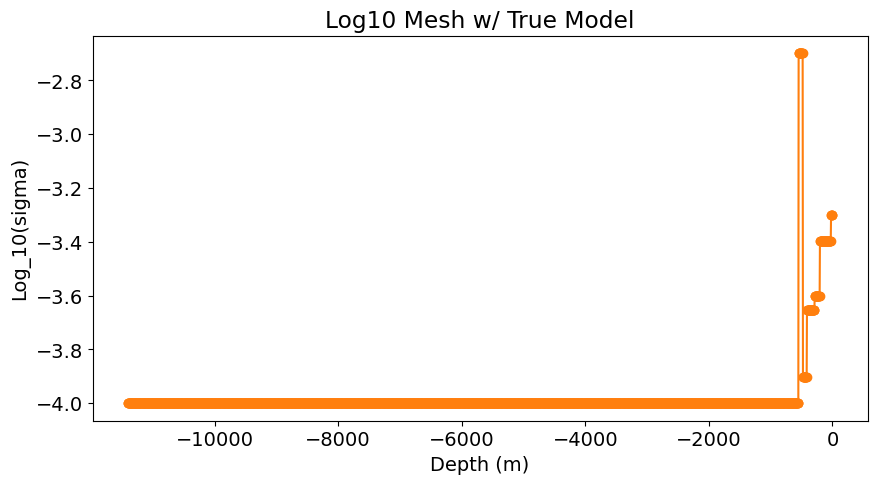

In [8]:
#Plotting Mesh with True Model
fig, ax = plt.subplots(1,1, figsize = (10,5))
mesh.plot_image(np.log10(model), ax = ax)
ax.set_title('Log10 Mesh w/ True Model')
ax.set_xlabel('Depth (m)')
ax.set_ylabel('Log_10(sigma)')

### Setting up 1D MT Simulation

In [9]:

############
#Creating Sigma map
sigma_map = maps.IdentityMap(nP=mesh.nC)# * wire_map.sigma # Extracting sigma from wire_map

#Setting up RX locations 
rx_loc_single = np.array([[0]])

#Receivers list
receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="real"),  #Only off diagonal components for 1D
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="imag"),

    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="real"),
    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="imag"),
]

source_list = []
for freq in frequencies:
    source_list.append(nsem.sources.Planewave(receivers_list, freq)) # Setting sources as plane waves at each specified frequencies 

survey = nsem.survey.Survey(source_list) #Creating survey object with given sources form source_list

#Creating simulation object
simulation = nsem.Simulation1DElectricField(mesh,
    survey=survey, 
    sigmaMap=sigma_map,
    solver = Mumps)

#Setting true model as previously obtained model
true_model = model

#creating predicted data on basis of true model + receivers, frequencies, orientations, etc.
dpred = simulation.dpred(true_model)
dobs = dpred # Saving for inversion purposes
dpred = dpred.reshape(len(frequencies),4)


In [10]:
#
Zxy = dpred[:,0]+ 1j* dpred[:,1]
Zyx = dpred[:,2] + 1j*dpred[:,3]

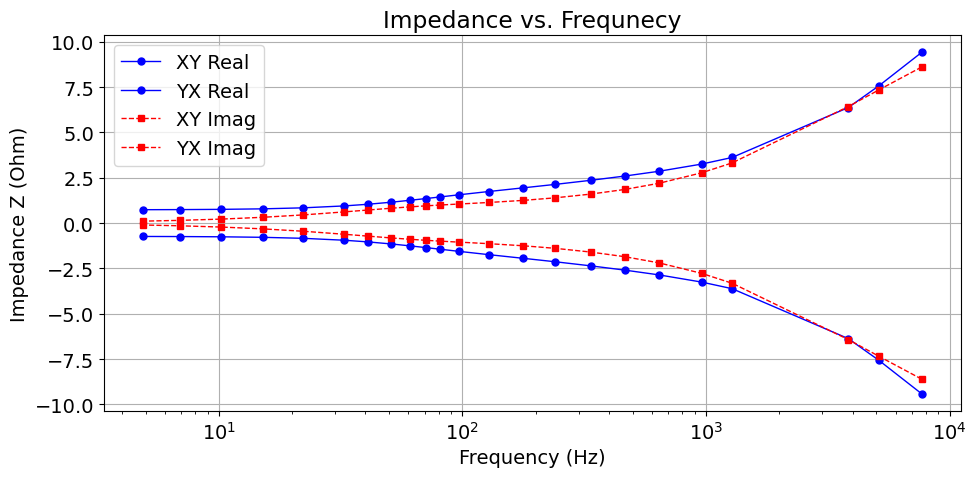

In [11]:
fig, ax = plt.subplots(1,1,figsize=(10, 5))

#Plotting Real Component XY and YX 
ax.semilogx(frequencies, dpred[:,0], "b-o", lw=1, ms=5, label = 'XY Real')
ax.semilogx(frequencies, dpred[:,2], "b-o", lw=1, ms=5, label = 'YX Real')

#Pting Imag Component XY and YX 
ax.semilogx(frequencies, dpred[:,1], "r--s", lw=1, ms=5, label = 'XY Imag')
ax.semilogx(frequencies, dpred[:,3], "r--s", lw=1, ms=5, label = 'YX Imag')

ax.grid()
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Impedance Z (Ohm)")
ax.set_title("Impedance vs. Frequnecy")
ax.legend

ax.legend()


fig.tight_layout()


In [12]:
#Defining Values to plot apparent resisitivity and phase
omega = 2*np.pi* frequencies

#Computing Apparent resisitvity and phase
apparent_rho = (np.abs(Zxy)**2)/ (scipy.constants.mu_0 * omega)
phase = np.rad2deg(np.arctan2( np.imag(Zxy),np.real(Zxy)))

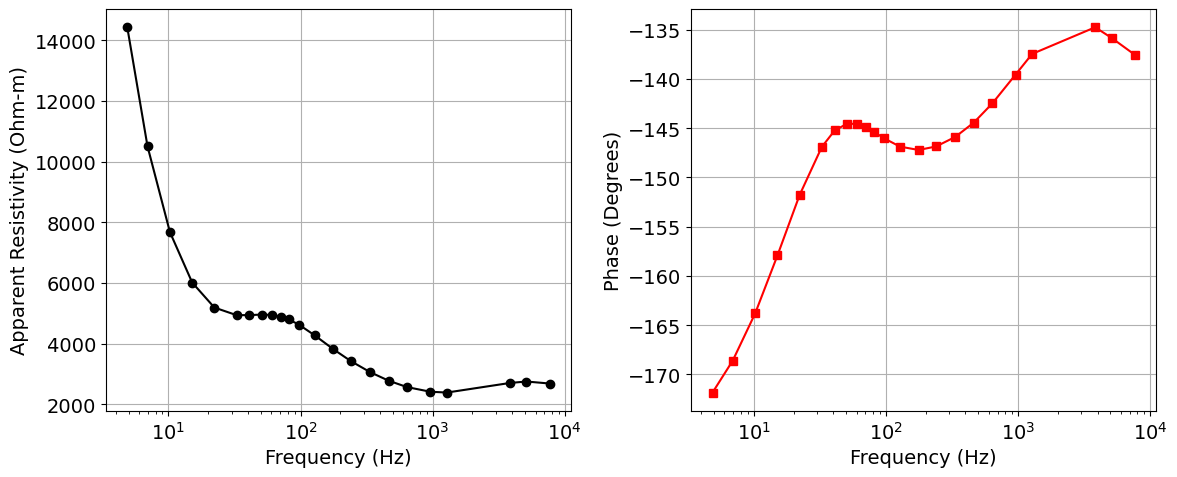

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

#Plotting Apparent Resisitivty
ax[0].semilogx(frequencies, apparent_rho, 'k-o')
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Apparent Resistivity (Ohm-m)")
ax[0].grid()

# Plotting Phase
ax[1].semilogx(frequencies, phase, 'r-s')
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Phase (Degrees)")
ax[1].grid()

plt.tight_layout()


### Test Inversion

##### Inversion is still being reviewed...

In [14]:
#Defining inversion function
dobs = dobs
standard_deviation = 0.5
rho_0 = 2000
rho_ref = 2500
maxIter=10
maxIterCG=30
maxIterLS=30
alpha_s=1e-10
alpha_z=1
beta0_ratio=1
coolingFactor = 2
coolingRate=1
chi_factor=1
p_s=0
p_z=0

layer_thicknesses_inv = layer_thicknesses[:6] # Layers without halfspace

n_layer = len(layer_thicknesses_inv) + 1 # Total Number of Layers + halfspace

mesh_inv = TensorMesh([(np.r_[layer_thicknesses_inv, layer_thicknesses_inv[-1]])], "N")

sigma_map = maps.ExpMap(nP = n_layer)
    
simulation = nsem.simulation_1d.Simulation1DRecursive(
    survey=survey, 
    sigmaMap=sigma_map,
    thicknesses=layer_thicknesses_inv,
)
# Define the data 
data_object = data.Data(survey, dobs=dobs, standard_deviation=standard_deviation)    

# Initial model
m0 = np.ones(n_layer) * np.log(1./rho_0)

# Reference model
mref = np.ones(n_layer) * np.log(1./rho_ref)    

dmis = data_misfit.L2DataMisfit(simulation=simulation, data=data_object)

# Define the regularization (model objective function)
reg = regularization.Sparse(
    mesh_inv, alpha_s=alpha_s, alpha_x=alpha_z, 
    reference_model=mref,
    reference_model_in_smooth=False,
    mapping=maps.IdentityMap(nP = n_layer),
)

# Define how the optimization problem is solved. Here we will use an inexact
# Gauss-Newton approach that employs the conjugate gradient solver.
opt = optimization.InexactGaussNewton(
maxIter=maxIter,
maxIterCG=maxIterCG,
maxIterLS=maxIterLS,
)


# Define the inverse problem
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

#######################################################################
# Define Inversion Directives
# ---------------------------
#
# Here we define any directives that are carried out during the inversion. This
# includes the cooling schedule for the trade-off parameter (beta), stopping
# criteria for the inversion and saving inversion results at each iteration.
#

# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=beta0_ratio)

# Set the rate of reduction in trade-off parameter (beta) each time the
# the inverse problem is solved. And set the number of Gauss-Newton iterations
# for each trade-off paramter value.
beta_schedule = directives.BetaSchedule(coolingFactor=coolingFactor, coolingRate=coolingRate)
save_dictionary = directives.SaveOutputDictEveryIteration()
save_dictionary.outDict = {}
# Setting a stopping criteria for the inversion.
target_misfit = directives.TargetMisfit(chifact=chi_factor)
precond = directives.UpdatePreconditioner()

# The directives are defined as a list.
directives_list = [
    precond,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_dictionary
]

#####################################################################
# Running the Inversion
# ---------------------
#
# To define the inversion object, we need to define the inversion problem and
# the set of directives. We can then run the inversion.
#

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

# Run the inversion
recovered_model = inv.run(m0)    
output_dict= save_dictionary.outDict
#return recovered_model, 


INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  5.62e+03  6.42e+03  3.09e-09  6.42e+03                                 
   1  5.62e+03  4.11e+03  1.94e-04  4.11e+03    1.45e+03      0              
   2  2.81e+03  3.78e+03  5.83e-03  3.79e+03    3.14e+02      0              
   3  1.40e+03  3.73e+03  1.63e-05  3.73e+03    5.25e+01      0              
   4  7.02e+02  3.72e+03  4.05e-06  3.72e+03    7.21e+00      0              
   5  3.51e+02  3.72e+03  6.31e-06  3.72e+03    1.04e+00      0              
   6  1.76e+02  3.72e+03  9.05e-06  3.72e+03    1.40e-01      0              
   7  8.78e+01  3.72e+03  1.23e-05  3.72e+03    1.90e-02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 1.6739e-02 <= tolF*(1+|f0|) 

In [15]:
target_misfit = dpred.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

In [16]:
matplotlib.rcParams['font.size'] = 14
def tikhonov_curve(iteration, scale='log'):
    fig, ax = plt.subplots(1,1, figsize=(5,5))
    ax.plot(phi_ms, phi_ds)
    ax.plot(phi_ms[iteration-1], phi_ds[iteration-1], 'ro')
    ax.set_xlabel(r"$\phi_m$")
    ax.set_ylabel(r"$\phi_d$")
    if scale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    xlim = ax.get_xlim()
    ax.plot(xlim, np.ones(2) * target_misfit, '--')
    ax.set_title("Iteration={:d}, Beta = {:.1e}".format(iteration, betas[iteration-1]))
    ax.set_xlim(xlim)
    plt.show()

In [17]:
from ipywidgets import interact, widgets
Q_iter = interact(
    tikhonov_curve, 
    iteration=widgets.IntSlider(min=1, max=int(n_iteration), value=n_iteration),
    scale=widgets.RadioButtons(options=['linear', 'log'])
)

interactive(children=(IntSlider(value=7, description='iteration', max=7, min=1), RadioButtons(description='sca…

In [18]:
# #Plotting
# iteration = 5
# dpred = output_dict[iteration]['dpred']
# m = output_dict[iteration]['m']
# fig = plt.figure(figsize=(16, 5))
# gs = gridspec.GridSpec(1, 5, figure=fig)

# ax0 = fig.add_subplot(gs[0, 0])
# plot_1d_layer_model(layer_thicknesses, 1/sigma) # figure has base value at log plot
# plot_1d_layer_model(
#     layer_thicknesses_inv,
#     1.0 / np.exp(m),
#     ax=ax0,
#     color="k",
#     label=r"$m_{Inv}$",
#     linestyle="--",
# )
# ax0.legend()
# ax0.set_xlabel(r"Resistivity [$\Omega$m]")
# ax0.set_title('Model from iteration ' + str(iteration), fontsize=14)
# ax0.grid(True, which='both', alpha=0.5)


# ax = fig.add_subplot(gs[0, 2:])
# ax.loglog(1./frequencies, dpred.reshape((len(frequencies), 2))[:,0], color='C0', label=r'$d_{pred}$ ($\rho_{a}$)')

# ax_1 = ax.twinx()
# ax_1.plot(1./frequencies, dpred.reshape((len(frequencies), 2))[:,1], color='C1', label=r'$d_{pred}$ ($\Phi$)')
# ax.set_xlabel("Period [s]")
# ax.grid(True, which='both', alpha=0.5)
# ax.set_ylabel(r"Apparent resistivity [$\Omega$m]")
# ax_1.set_ylabel(r"Phase [$\degree$]")
# # ax.legend(bbox_to_anchor=(1.1,1))
# ax.legend(loc=2)
# ax_1.legend(loc=1)
# plt.show()